In [76]:
import pandas as pd
import plotly.express as px

In [78]:
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
print('The files have been read!')

The files have been read!


In [79]:
merged_order_items = pd.merge(orders, order_items, on='order_id')
merged_customers = pd.merge(merged_order_items, customers, on='customer_id')
merged_products = pd.merge(merged_customers, products, on='product_id')
translation = pd.merge(merged_products, translation, on='product_category_name')

In [80]:
print(translation.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1155
order_delivered_customer_date    2386
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    1
product_length_cm                   1
product_height_cm                   1
product_width_cm                    1
product_cate

In [81]:
translation['order_purchase_timestamp'] = pd.to_datetime(translation['order_purchase_timestamp'])
translation['month_year'] = translation['order_purchase_timestamp'].dt.to_period('M').astype(str)

In [82]:
top_categories = translation.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_categories)

  product_category_name_english       price
0                 health_beauty  1258681.34
1                 watches_gifts  1205005.68
2                bed_bath_table  1036988.68
3                sports_leisure   988048.97
4         computers_accessories   911954.32
5               furniture_decor   729762.49
6                    cool_stuff   635290.85
7                    housewares   632248.66
8                          auto   592720.11
9                  garden_tools   485256.46


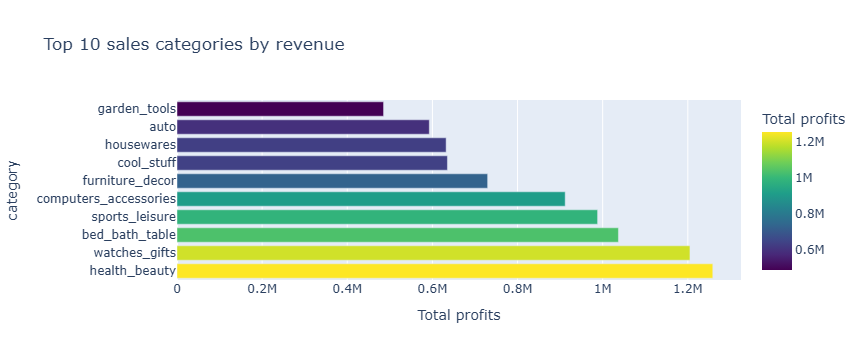

In [90]:
fig = px.bar(top_categories, 
             x='price', 
             y='product_category_name_english', 
             orientation='h',
             title='Top 10 sales categories by revenue',
             labels={'price':'Total profits', 'product_category_name_english':'category'},
             color='price',
             color_continuous_scale='Viridis')
fig.show()

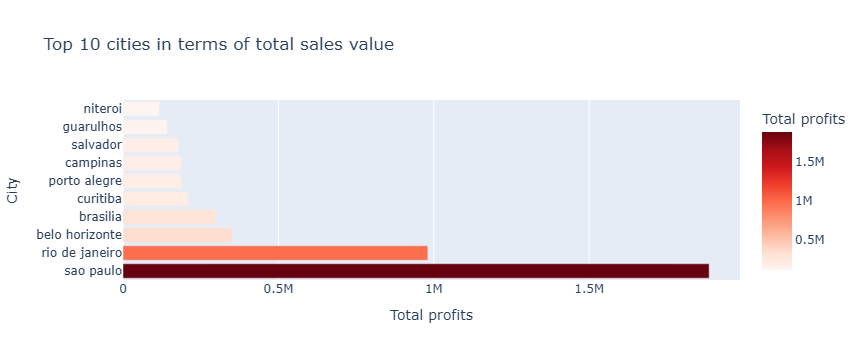

In [92]:
city_sales = translation.groupby('customer_city')['price'].sum().sort_values(ascending=False).head(10).reset_index()
fig_city = px.bar(city_sales, 
                  x='price', 
                  y='customer_city', 
                  orientation='h',
                  title='Top 10 cities in terms of total sales value',
                  labels={'price':'Total profits', 'customer_city':'City'},
                  color='price',
                  color_continuous_scale='Reds')
fig_city.show()

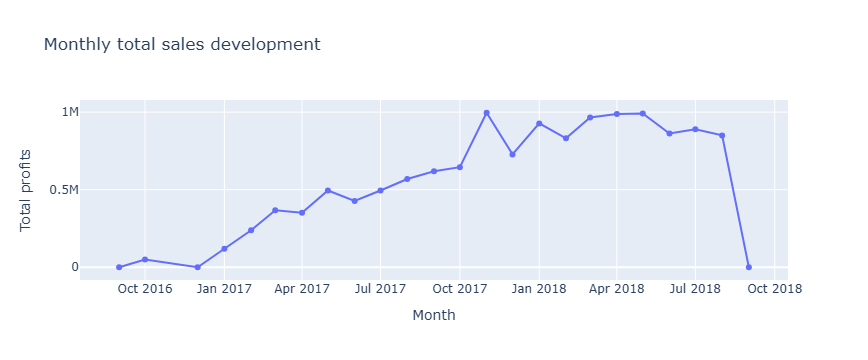

In [94]:
monthly_trend = translation.groupby('month_year')['price'].sum().reset_index()

fig_trend = px.line(monthly_trend, 
                    x='month_year', 
                    y='price', 
                    title='Monthly total sales development',
                    labels={'month_year':'Month', 'price':'Total profits'},
                    markers=True)
fig_trend.show()